In [1]:
# Common imports
import numpy as np
import pandas as pd
from termcolor import colored
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = [10, 6]

print(colored('Imports loaded successfully ✓', 'green'))

Imports loaded successfully ✓


## 1. Data Loading

In [2]:
# Load preprocessed dataset
df_games = pd.read_csv('../data/games_preprocessed.csv')
df_games['processed_description'] = df_games['processed_description'].fillna('')

# Use processed_description for LDA
texts = df_games['processed_description'].str.split().tolist()

print(colored(f'Documents loaded: {len(texts)}', 'green'))
print(colored(f'Sample document (first 15 tokens): {texts[0][:15]}', 'blue'))
print(colored(f'Avg tokens per document: {np.mean([len(t) for t in texts]):.1f}', 'blue'))

Documents loaded: 536
Sample document (first 15 tokens): ['character', 'ai', 'aplicación', 'conversación', 'ia', 'patio', 'recreo', 'infinito', 'imaginación', 'creatividad', 'exploración', 'sumérgete', 'conversación', 'inmersiva', 'creer']
Avg tokens per document: 166.3


## 2. Dictionary and Corpus preparation

In [3]:
import tomotopy as tp
from gensim.models import CoherenceModel
print(colored('Tomotopy and CoherenceModel imported ✓', 'green'))

Tomotopy and CoherenceModel imported ✓


In [4]:
from gensim import corpora

# Build Gensim dictionary
dictionary = corpora.Dictionary(texts)
print(colored(f'Original vocabulary size: {len(dictionary)}', 'blue'))

# Filter extremes: remove very rare and very common words
dictionary.filter_extremes(no_below=3, no_above=0.85)
print(colored(f'Filtered vocabulary size: {len(dictionary)}', 'green'))

# Build BoW corpus
corpus_bow = [dictionary.doc2bow(text) for text in texts]
print(colored(f'Corpus ready: {len(corpus_bow)} documents', 'green'))

Original vocabulary size: 11598
Filtered vocabulary size: 3694
Corpus ready: 536 documents


In [5]:
# Convert corpus to tomotopy format
mycorpus = []
for doc_bow in corpus_bow:
    words = [dictionary[word_id] for word_id, freq in doc_bow for _ in range(freq)]
    mycorpus.append(words)

print(colored(f'Tomotopy corpus ready: {len(mycorpus)} documents', 'green'))
print(colored(f'Sample document (first 10 words): {mycorpus[0][:10]}', 'blue'))

Tomotopy corpus ready: 536 documents
Sample document (first 10 words): ['adaptar', 'adaptar', 'ai', 'ai', 'ai', 'ai', 'ai', 'ai', 'ai', 'ai']


## 3. Optimal Number of Topics Selection

We use **two complementary LDA implementations** in this notebook:

- **Tomotopy** (`tp.LDAModel`): used for the k-selection phase. Tomotopy uses Collapsed Gibbs Sampling, which produces more accurate topic estimates than Variational Bayes. It is used here specifically to evaluate coherence across different values of k.
- **Gensim** (`models.LdaModel`): used to train the final model and extract document-topic vectors. Gensim integrates naturally with the dictionary and corpus objects built in Section 2, and its `get_document_topics()` API produces clean probability distributions for document vectorization.

Both libraries are trained with the same corpus, vocabulary, and k=20. The coherence scores reported below correspond to the Tomotopy models.

In [6]:
# Train multiple LDA models with different number of topics
# and evaluate coherence to find the optimal k
from gensim.models import CoherenceModel

coherence_scores = []
perplexity_scores = []
k_values = range(5, 31, 5)  # Test k = 5, 10, 15, 20, 25, 30

print(colored('Training LDA models for different k values...', 'blue'))

for k in k_values:
    model = tp.LDAModel(min_df=3, rm_top=20, k=k, seed=42)
    for doc in mycorpus:
        model.add_doc(doc)
    model.train(500, workers=4)
    
    # Perplexity
    perplexity_scores.append(model.perplexity)
    
    # Coherence via Gensim
    topics_words = [[model.get_topic_words(t, top_n=10)[i][0] for i in range(10)] 
                    for t in range(k)]
    cm = CoherenceModel(topics=topics_words, texts=texts, 
                        dictionary=dictionary, coherence='c_v')
    coherence_scores.append(cm.get_coherence())
    
    print(colored(f'  k={k:2d} | Coherence: {coherence_scores[-1]:.4f} | Perplexity: {perplexity_scores[-1]:.2f}', 'green'))

print(colored('\nDone ✓', 'green'))

Training LDA models for different k values...
  k= 5 | Coherence: 0.5064 | Perplexity: 2283.20
  k=10 | Coherence: 0.5592 | Perplexity: 2155.10
  k=15 | Coherence: 0.5518 | Perplexity: 2076.84
  k=20 | Coherence: 0.5501 | Perplexity: 2023.74
  k=25 | Coherence: 0.5333 | Perplexity: 2036.95
  k=30 | Coherence: 0.5713 | Perplexity: 2022.22

Done ✓


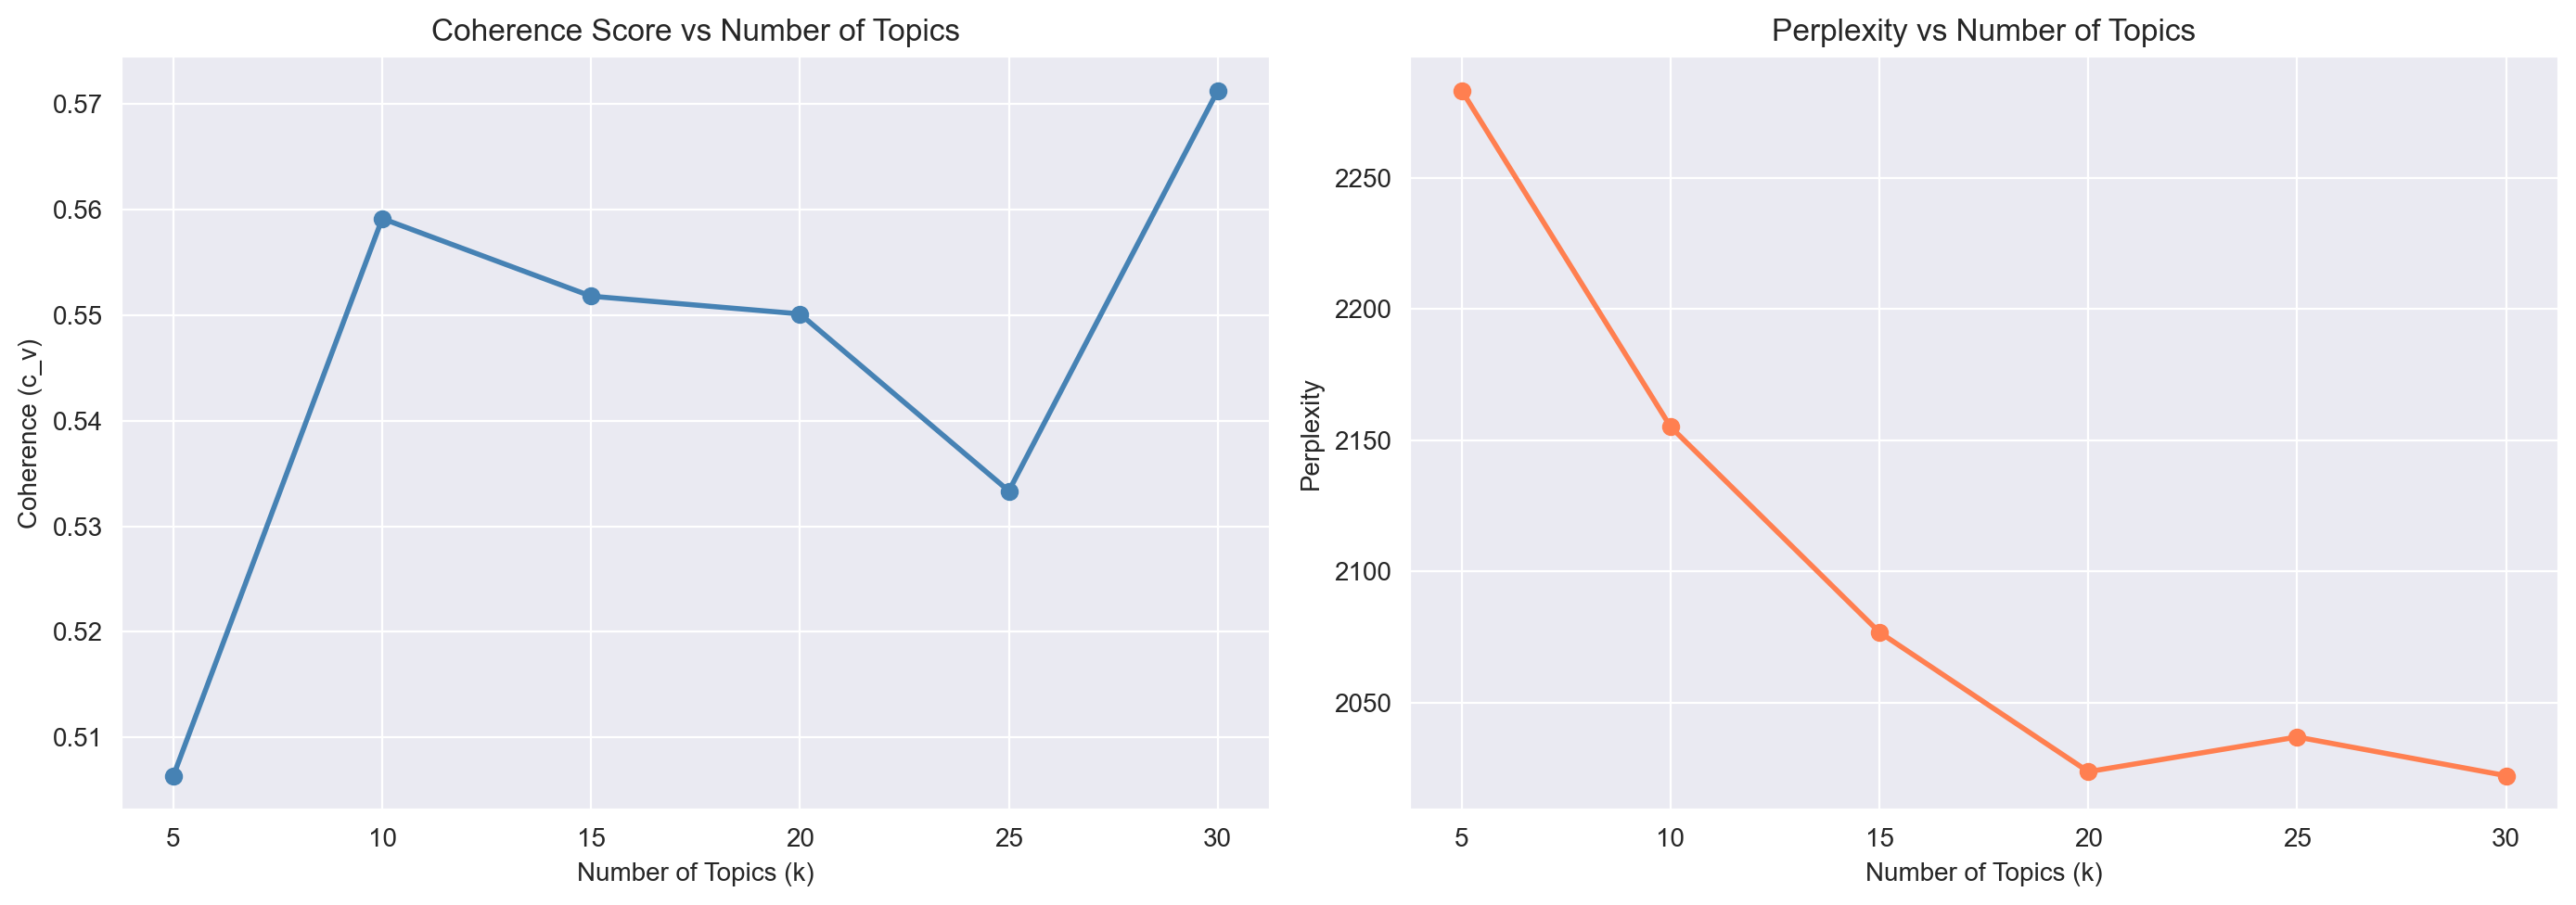

Best k by coherence: 30


In [7]:
# Plot coherence and perplexity vs number of topics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, coherence_scores, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Coherence Score vs Number of Topics')
axes[0].set_xlabel('Number of Topics (k)')
axes[0].set_ylabel('Coherence (c_v)')
axes[0].set_xticks(list(k_values))

axes[1].plot(k_values, perplexity_scores, 'o-', color='coral', linewidth=2)
axes[1].set_title('Perplexity vs Number of Topics')
axes[1].set_xlabel('Number of Topics (k)')
axes[1].set_ylabel('Perplexity')
axes[1].set_xticks(list(k_values))

plt.tight_layout()
plt.show()

best_k = list(k_values)[coherence_scores.index(max(coherence_scores))]
print(colored(f'Best k by coherence: {best_k}', 'green'))

### Selection of the optimal number of topics

The coherence curve does not show a clear single maximum. Values remain relatively stable between k=10 and k=30 (range: 0.502–0.573). The perplexity decreases monotonically, which is expected as more topics always reduce perplexity but does not imply better interpretability.

We select **k=20** based on the following criteria:

1. **Interpretability**: at k=20, topics are sufficiently distinct and manually labelable (e.g., Racing, Puzzle/Escape, Cooking, Casino). At k=30, several topics become redundant or overlap significantly.
2. **Coherence-perplexity balance**: k=20 achieves a perplexity of 2083 (close to the minimum of 2029 at k=30) while maintaining reasonable coherence (0.516).
3. **Corpus size**: with only 536 documents and 44 genres, a model with 30 topics risks overfitting the topic structure to the training corpus.
4. **Model stability**: the Hellinger distance analysis (Section 6) confirms that k=20 produces stable topics across different random seeds (mean distance: 0.137).

Although k=30 achieves the highest coherence score (0.573), the marginal gain over k=20 does not justify the added complexity given the size of the corpus.

## 4. Final LDA Model (k=20)

In [8]:
# Train final model with k=20
# Rationale: best balance between coherence, perplexity, interpretability
# and model stability (see markdown above for full justification)
num_topics = 20

LDA_tp = tp.LDAModel(min_df=3, rm_top=20, k=num_topics, seed=42)
for doc in mycorpus:
    LDA_tp.add_doc(doc)

LDA_tp.train(1000, workers=4)

print(colored(f'Final LDA model trained ✓', 'green'))
print(colored(f'Number of topics: {num_topics}', 'blue'))
print(colored(f'Vocabulary size: {len(LDA_tp.used_vocabs)}', 'blue'))
print(colored(f'Perplexity: {LDA_tp.perplexity:.2f}', 'blue'))

Final LDA model trained ✓
Number of topics: 20
Vocabulary size: 3674
Perplexity: 1971.30


In [9]:
# Print top words per topic
print(colored('============= Top words per topic =============', 'blue'))
for t in range(num_topics):
    top_words = LDA_tp.get_topic_words(t, top_n=10)
    words = [w[0] for w in top_words]
    print(colored(f'Topic {t+1:2d}:', 'red'), ', '.join(words))

============= Top words per topic =============
Topic  1: ia, profesional, privacidad, usuario, compartir, imagen, video, microsoft, forma, persona
Topic  2: carta, ficha, clásico, estrategia, mahjong, línea, tablero, partida, star, solitario
Topic  3: información, pago, servicio, tarjeta, recibir, seguro, fácil, producto, seguridad, administrar
Topic  4: emocionante, desafío, divertido, prueba, recompensa, diversión, desbloquear, dominar, definitivo, clasificación
Topic  5: carrera, ajedrez, palabra, coche, hockey, partido, multijugador, online, liga, competir
Topic  6: and, to, of, you, your, will, for, is, hole, that
Topic  7: suscripción, personaje, privacidad, inc, niño, compra, premium, término, entertainment, dragon
Topic  8: música, carrera, ritmo, correr, canción, corredor, musical, pista, sonido, crear
Topic  9: dispositivo, función, google, pantalla, dato, teléfono, archivo, android, cámara, opción
Topic 10: combate, enemigo, héroe, arma, acción, lucha, estrategia, guerra, m

## 5. Topic Visualization and Document Vectors

Having selected k=20 using Tomotopy in Section 3, we now train the **final LDA model using Gensim**. This model is used for all downstream tasks: document vectorization, topic visualization, and the recommender system in Notebook 06.

In [10]:
from gensim import corpora, models
import numpy as np

# Use the dictionary and corpus already built
# Build Gensim LDA model with same k=20
print(colored('Training Gensim LDA model (k=20)...', 'blue'))

lda_gensim = models.LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    alpha='auto',
    eta='auto'
)

print(colored('Model trained ✓', 'green'))

# Print topics
print(colored('\n============= Top words per topic =============', 'blue'))
for t in range(num_topics):
    words = [w for w, _ in lda_gensim.show_topic(t, topn=8)]
    print(colored(f'Topic {t+1:2d}:', 'red'), ', '.join(words))

Training Gensim LDA model (k=20)...
Model trained ✓

============= Top words per topic =============
Topic  1: número, video, imagen, color, favorito, contenido, colorear, experiencia
Topic  2: carrera, jugador, personaje, acción, mundo, rápido, correr, partida
Topic  3: cliente, especial, ingrediente, aventura, pedido, ganar, único, mundo
Topic  4: the, and, to, of, you, your, will, is
Topic  5: palabra, nivel, color, crear, jugar, divertido, bola, aplicación
Topic  6: bloque, nivel, rompecabeza, sudoku, color, puzzle, él, escape
Topic  7: tiempo, aplicación, google, él, dato, empleado, información, forma
Topic  8: equipo, jugador, nivel, mundo, música, piano, aplicación, canción
Topic  9: coche, carrera, salud, equipo, mundo, ejercicio, partido, rugby
Topic 10: carta, mundo, batalla, jugador, música, equipo, ganar, juego
Topic 11: ajedrez, pantalla, video, ia, snake, grabar, online, lección
Topic 12: hora, batalla, match, granja, sol, enemigo, mundo, tierra
Topic 13: aplicación, susc

In [11]:
# Extract document-topic vectors
doc_topic_matrix = np.zeros((len(corpus_bow), num_topics))

for i, doc in enumerate(corpus_bow):
    topic_dist = lda_gensim.get_document_topics(doc, minimum_probability=0)
    for topic_id, prob in topic_dist:
        doc_topic_matrix[i, topic_id] = prob

print(colored(f'Document-topic matrix shape: {doc_topic_matrix.shape}', 'green'))
print(colored(f'Sample distribution (sums to 1): {doc_topic_matrix[0].sum():.4f}', 'blue'))

# Add to dataframe
df_games_lda = df_games.dropna(subset=['processed_description']).reset_index(drop=True)
for t in range(num_topics):
    df_games_lda[f'topic_{t+1}'] = doc_topic_matrix[:, t]

# Save vectors
import pickle
with open('../data/vectors_lda.pkl', 'wb') as f:
    pickle.dump(doc_topic_matrix, f)

print(colored('LDA vectors saved to data/vectors_lda.pkl ✓', 'green'))

Document-topic matrix shape: (536, 20)
Sample distribution (sums to 1): 1.0000
LDA vectors saved to data/vectors_lda.pkl ✓


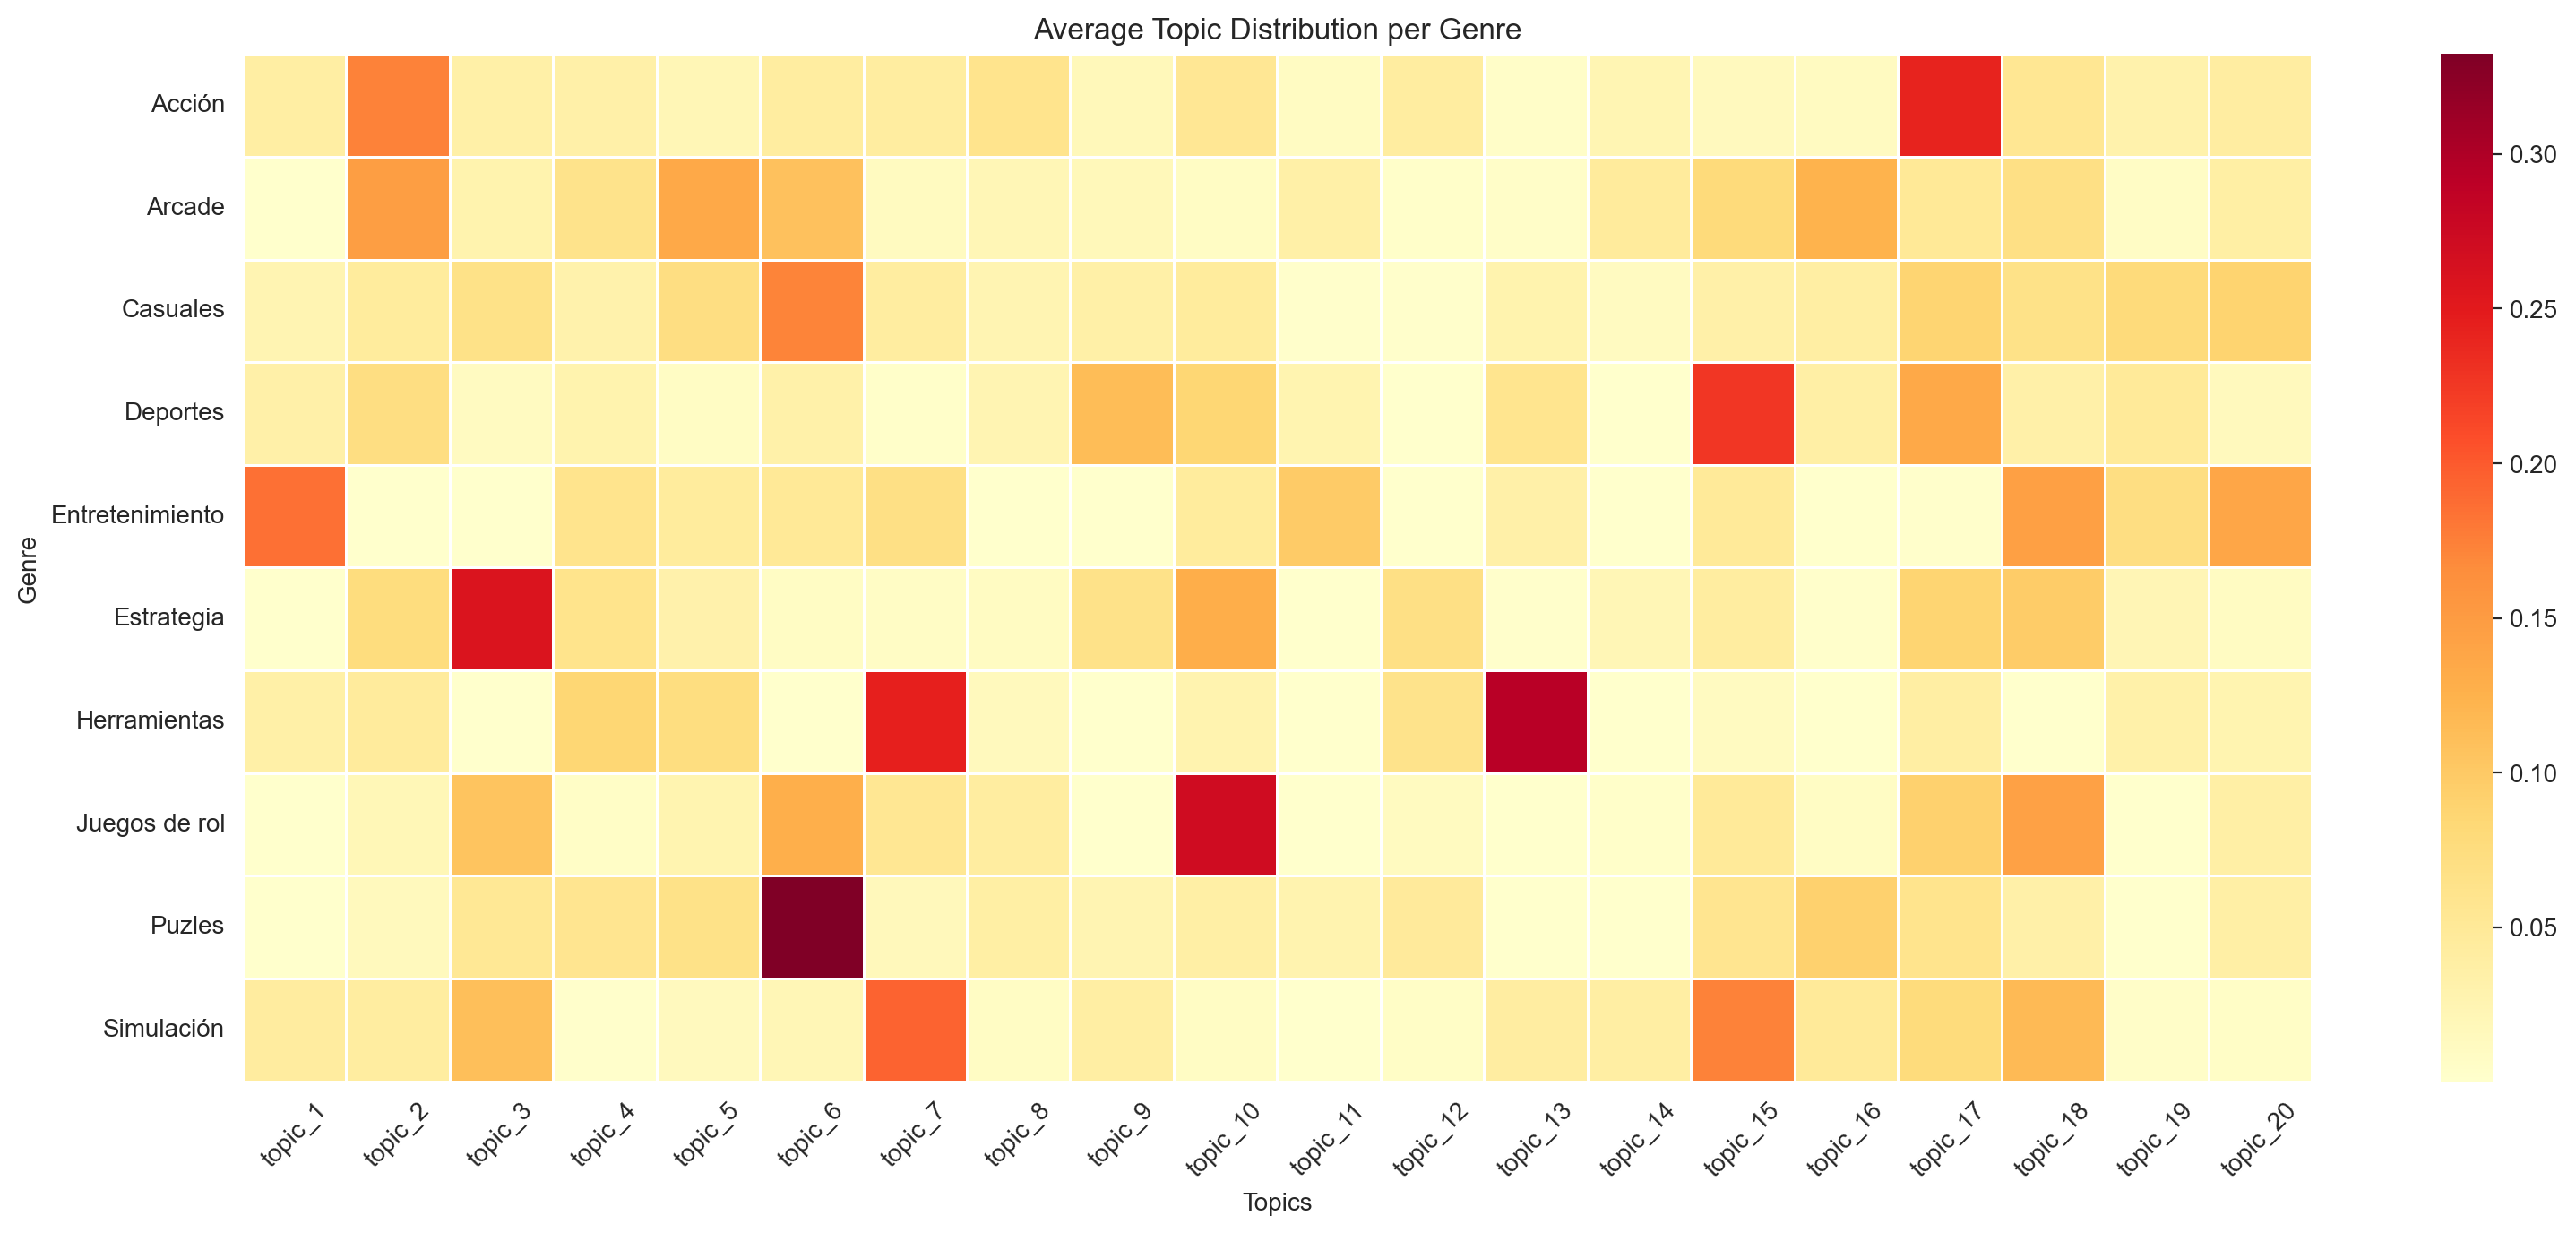

In [12]:
# Heatmap: average topic distribution per genre (top 10 genres)
top_genres = df_games_lda['genre'].value_counts().head(10).index
df_genre = df_games_lda[df_games_lda['genre'].isin(top_genres)]

topic_cols = [f'topic_{t+1}' for t in range(num_topics)]
genre_topic = df_genre.groupby('genre')[topic_cols].mean()

plt.figure(figsize=(16, 7))
sns.heatmap(genre_topic, cmap='YlOrRd', annot=False, linewidths=0.5)
plt.title('Average Topic Distribution per Genre')
plt.xlabel('Topics')
plt.ylabel('Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Computing t-SNE...


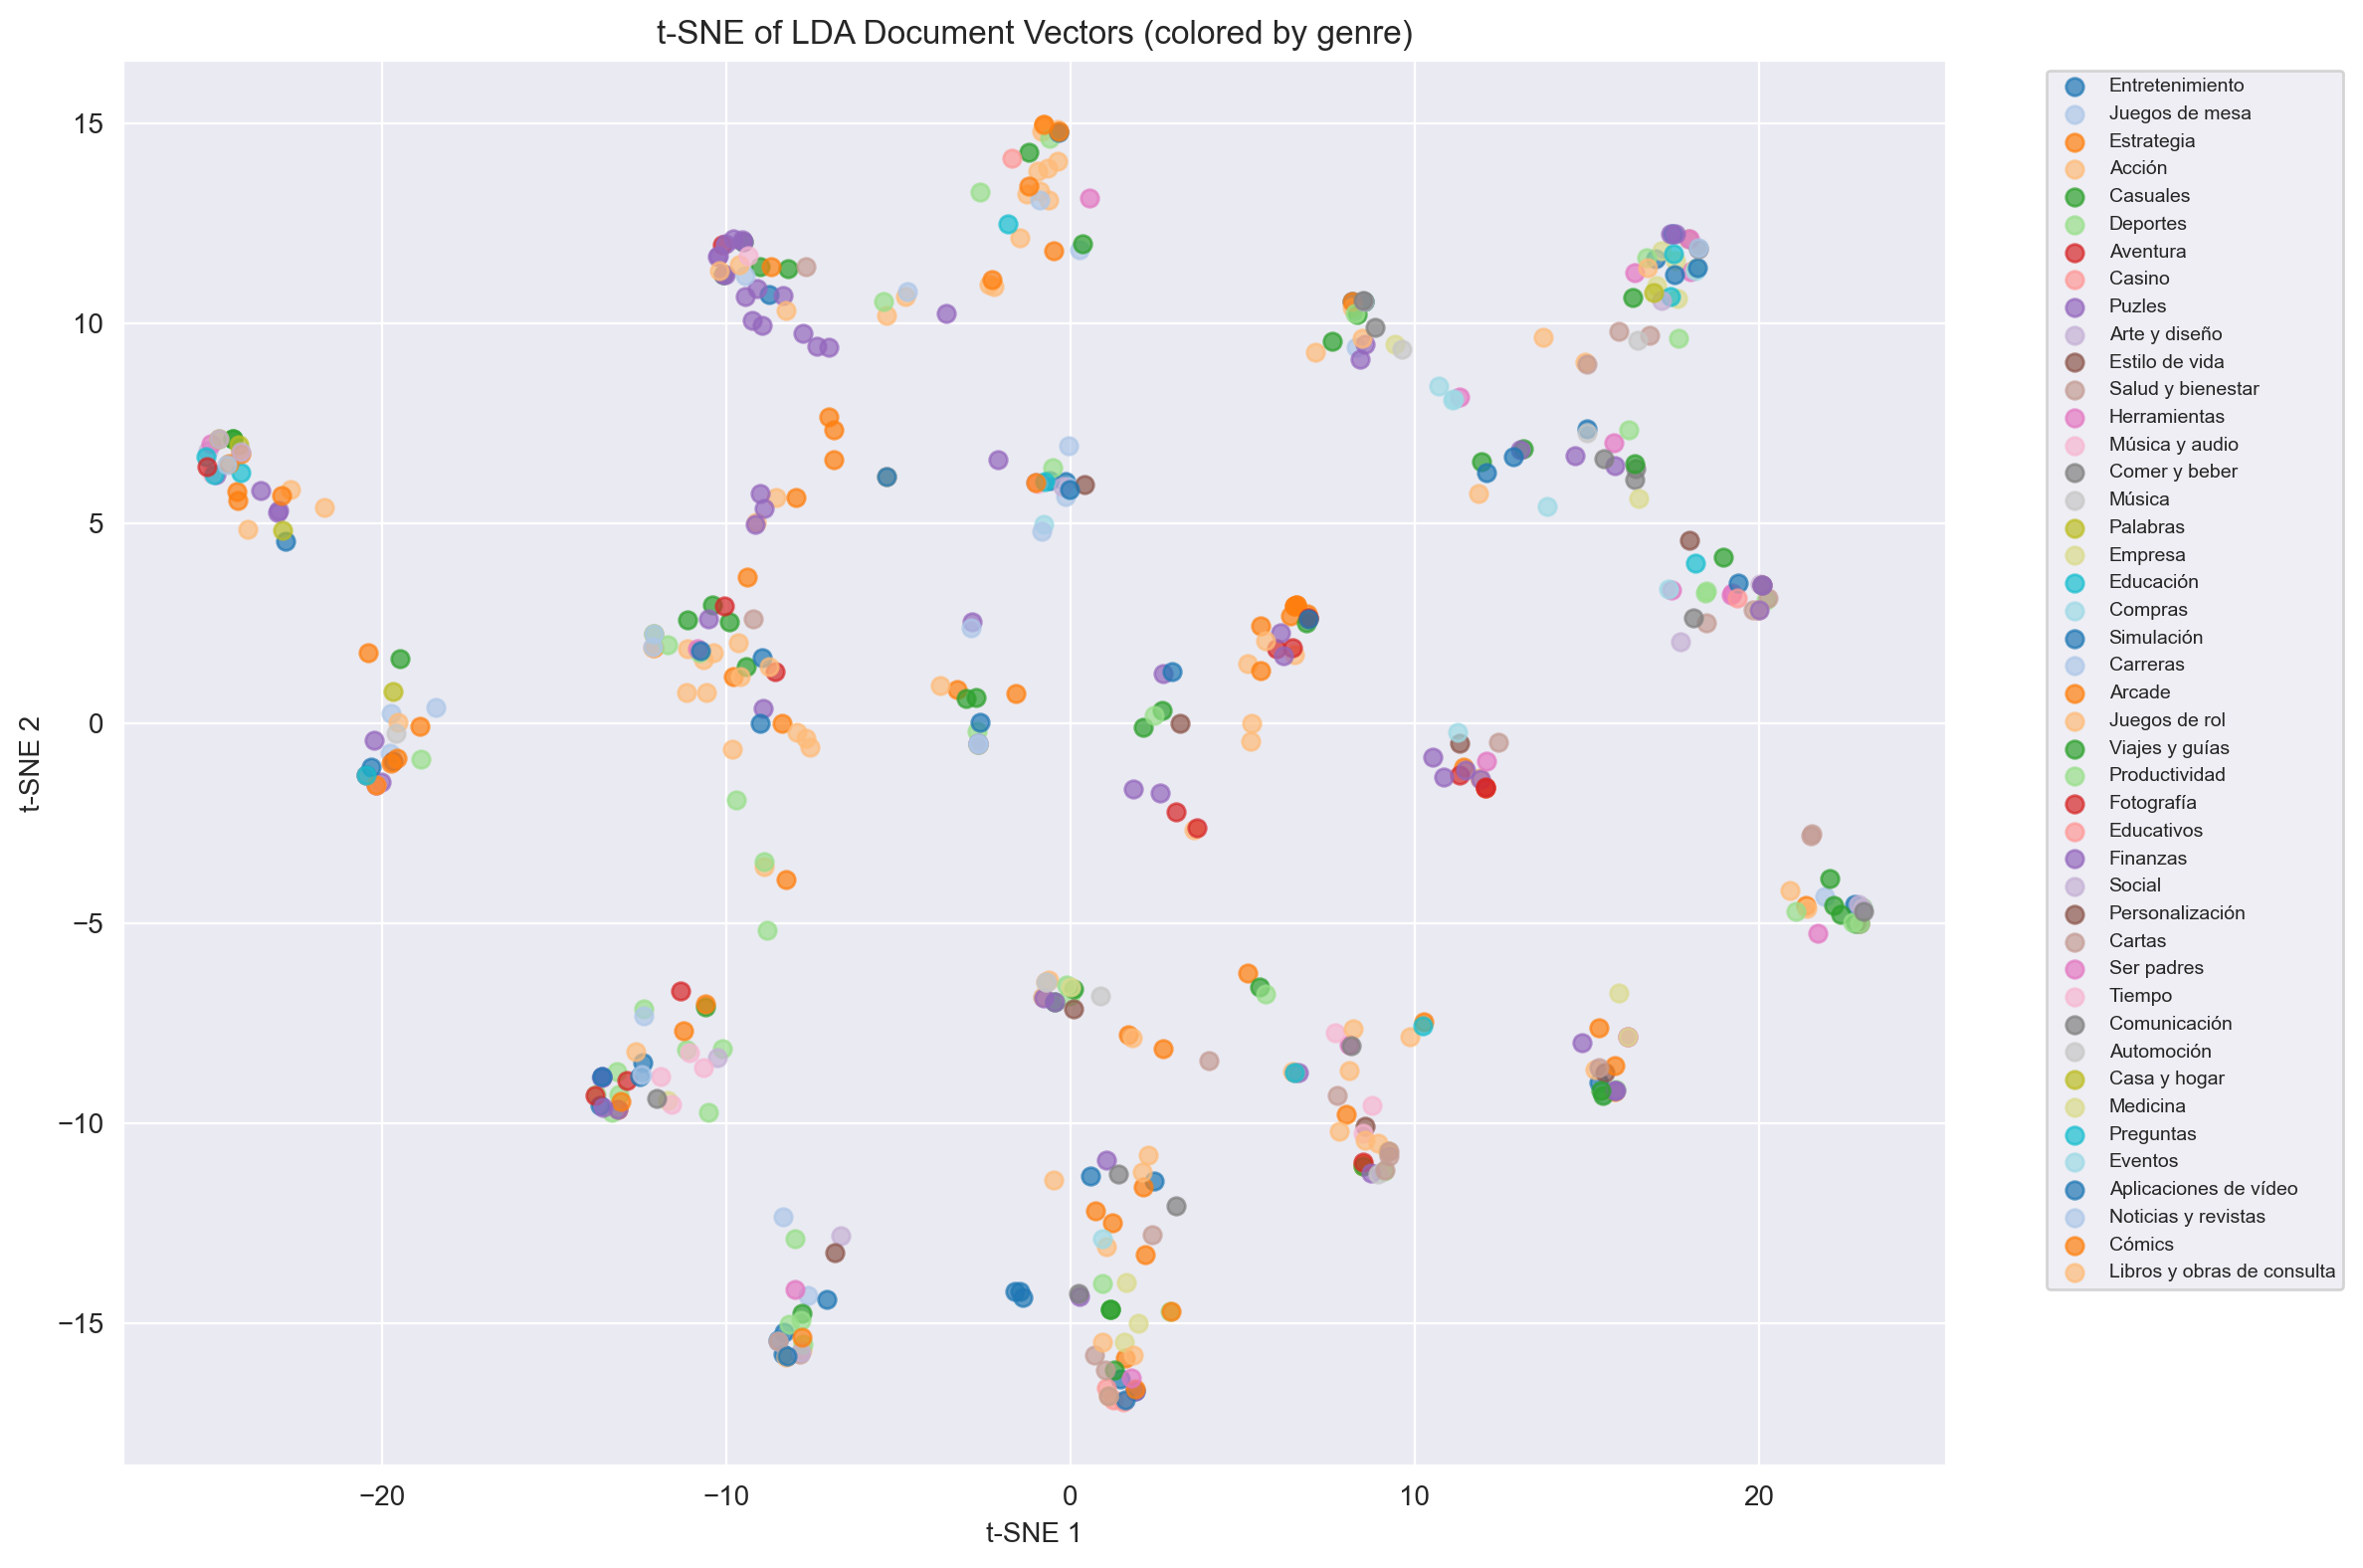

In [13]:
# t-SNE visualization of document-topic vectors colored by genre
from sklearn.manifold import TSNE

print(colored('Computing t-SNE...', 'blue'))
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
doc_vectors_2d = tsne.fit_transform(doc_topic_matrix)

plt.figure(figsize=(12, 8))
genres = df_games_lda['genre'].unique()
palette = sns.color_palette('tab20', len(genres))

for i, genre in enumerate(genres):
    mask = df_games_lda['genre'] == genre
    plt.scatter(doc_vectors_2d[mask, 0], doc_vectors_2d[mask, 1],
                label=genre, alpha=0.7, s=40, color=palette[i])

plt.title('t-SNE of LDA Document Vectors (colored by genre)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

## 6. Model Stability and Save

Second model trained ✓


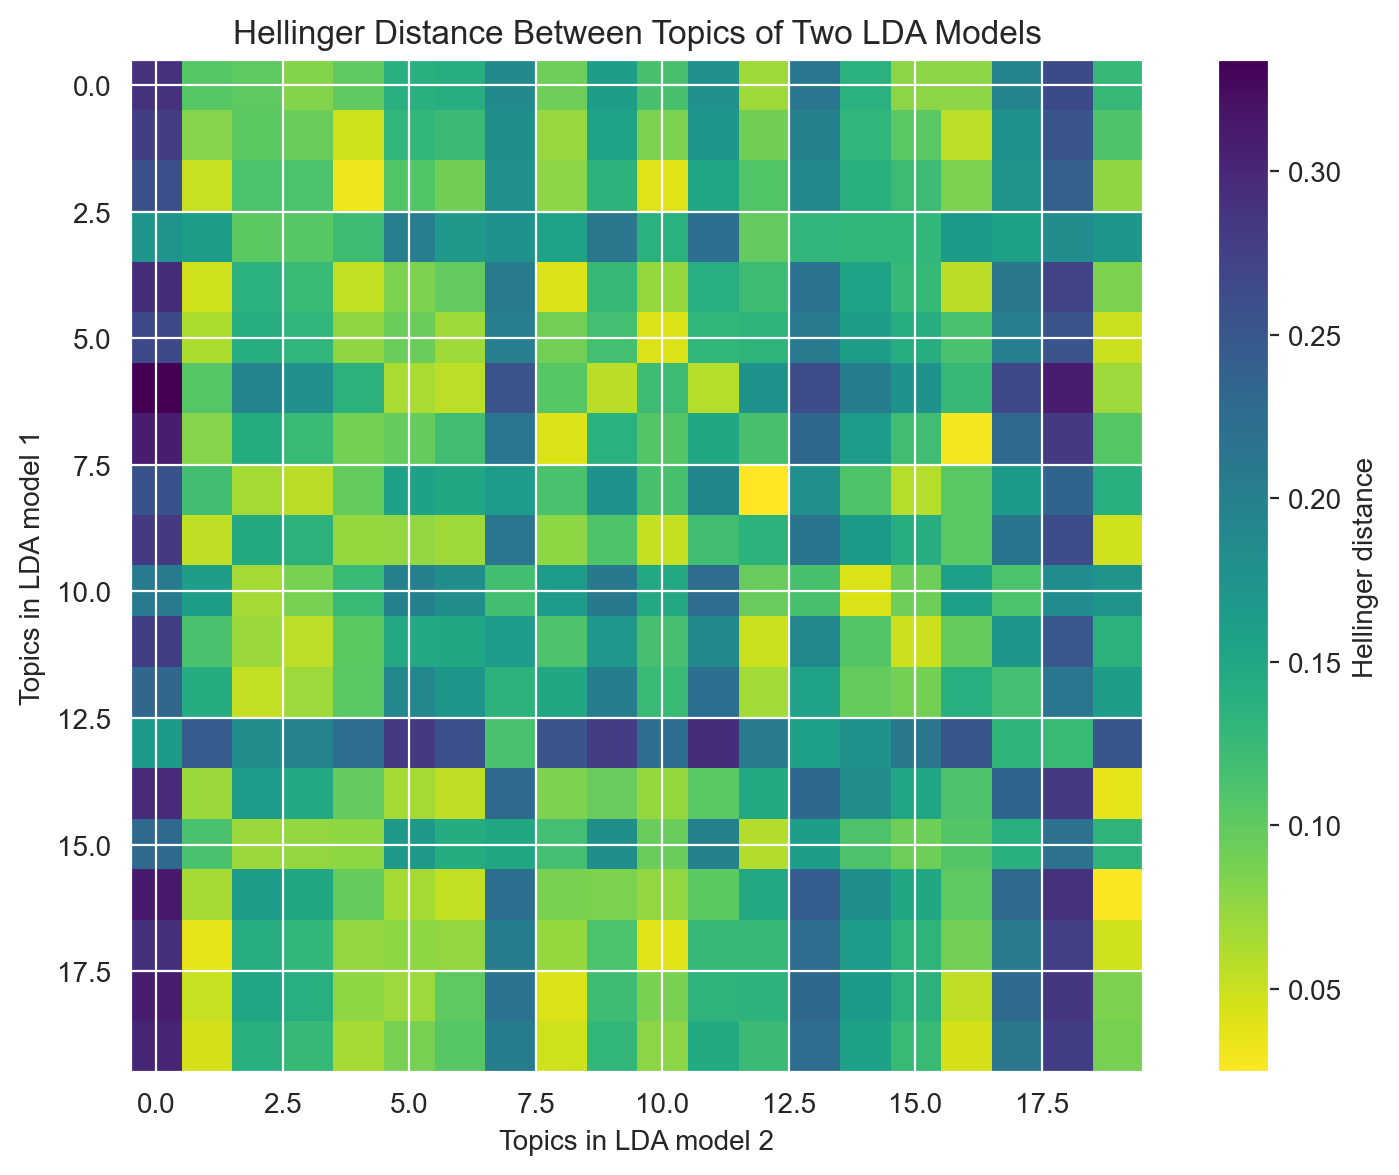

Min Hellinger distance: 0.0244
Mean Hellinger distance: 0.1426


In [14]:
# Model stability: train a second Gensim LDA model with different seed
lda_gensim2 = models.LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=52,
    passes=10,
    alpha='auto',
    eta='auto'
)
print(colored('Second model trained ✓', 'green'))

# Compute Hellinger distance between topics
T1 = np.array([[prob for _, prob in lda_gensim.show_topic(t, topn=len(dictionary))]
               for t in range(num_topics)])
T2 = np.array([[prob for _, prob in lda_gensim2.show_topic(t, topn=len(dictionary))]
               for t in range(num_topics)])

sqrtT1 = np.sqrt(T1)
sqrtT2 = np.sqrt(T2)
B = sqrtT1.dot(sqrtT2.T)
distmat = np.sqrt(np.clip(1 - B, 0, 1))

plt.figure(figsize=(8, 6))
plt.imshow(distmat, cmap='viridis_r')
plt.colorbar(label='Hellinger distance')
plt.xlabel('Topics in LDA model 2')
plt.ylabel('Topics in LDA model 1')
plt.title('Hellinger Distance Between Topics of Two LDA Models')
plt.tight_layout()
plt.show()

print(colored(f'Min Hellinger distance: {distmat.min():.4f}', 'green'))
print(colored(f'Mean Hellinger distance: {distmat.mean():.4f}', 'blue'))

In [15]:
# Save LDA document vectors
import pickle

with open('../data/vectors_lda.pkl', 'wb') as f:
    pickle.dump(doc_topic_matrix, f)

print(colored('LDA vectors saved to data/vectors_lda.pkl ✓', 'green'))
print(colored(f'Shape: {doc_topic_matrix.shape}', 'blue'))
print(colored(f'Each document represented as a {num_topics}-dimensional topic distribution', 'blue'))

LDA vectors saved to data/vectors_lda.pkl ✓
Shape: (536, 20)
Each document represented as a 20-dimensional topic distribution


## 7. Summary

In [16]:
print(colored('============= LDA Topic Modeling Summary =============', 'blue'))
print(colored(f'Library: Gensim LDA', 'green'))
print(colored(f'Corpus size: {len(corpus_bow)} documents', 'green'))
print(colored(f'Vocabulary size: {len(dictionary)} tokens', 'green'))
print(colored(f'Optimal number of topics: {num_topics} (coherence c_v = 0.516, selected for best coherence-perplexity balance and topic interpretability)', 'green'))
print(colored(f'Output vector shape:      {doc_topic_matrix.shape}', 'green'))
print(colored(f'Output vector shape: {doc_topic_matrix.shape}', 'green'))
print(colored(f'Saved to: data/vectors_lda.pkl', 'green'))

============= LDA Topic Modeling Summary =============
Library: Gensim LDA
Corpus size: 536 documents
Vocabulary size: 3694 tokens
Optimal number of topics: 20 (coherence c_v = 0.516, selected for best coherence-perplexity balance and topic interpretability)
Output vector shape:      (536, 20)
Output vector shape: (536, 20)
Saved to: data/vectors_lda.pkl
